<a href="https://colab.research.google.com/github/pavishanth-sujeevan/E.motion-/blob/llm/sinllama_therapy_COMPLETE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SinLLaMA Sinhala Therapy - Complete Training & Evaluation

### Model Architecture

```
LLaMA 3-8B (base)
    ↓
SinLLaMA Adapter (Sinhala specialization - 139K tokens)
    ↓
Therapy LoRA (empathetic response training)
```

In [ ]:
!pip install -q -U transformers peft accelerate bitsandbytes trl datasets
!pip install -q -U evaluate rouge_score sacrebleu matplotlib seaborn gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 156.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 56.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 6.7 MB/s eta 0:00:00


## 1. Setup & Installation

Install required packages for training and evaluation.

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainerCallback
from peft import PeftModel, LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
import evaluate

# Display system info
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


---

## 2. Data Loading

Mount Google Drive and load the Sinhala therapy dataset.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Data paths
DATA_DIR = "/content/drive/MyDrive/processed_sinhala_1"
TRAIN_FILE = f"{DATA_DIR}/train_si.jsonl"
VAL_FILE = f"{DATA_DIR}/val_si.jsonl"
TEST_FILE = f"{DATA_DIR}/test_si.jsonl"

# Verify files exist
import os
for filepath in [TRAIN_FILE, VAL_FILE, TEST_FILE]:
    assert os.path.exists(filepath), f"File not found: {filepath}"

print("✓ All data files found")

Mounted at /content/drive
✓ All data files found


In [ ]:
# Model identifiers
BASE_MODEL_ID = "meta-llama/Meta-Llama-3-8B"
SINLLAMA_ADAPTER = "polyglots/SinLlama_v01"
OUTPUT_DIR = "./sinllama-therapy-new"

print("Configuration:")
print(f"  Base: {BASE_MODEL_ID}")
print(f"  SinLLaMA: {SINLLAMA_ADAPTER}")
print(f"  Output: {OUTPUT_DIR}")
print("\nSinLLaMA = Native Sinhala language model")

Configuration:
  Base: meta-llama/Meta-Llama-3-8B
  SinLLaMA: polyglots/SinLlama_v01
  Output: ./sinllama-therapy-new

SinLLaMA = Native Sinhala language model


In [ ]:
def load_data(filepath):
    """
    Load Sinhala therapy data
    """
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                entry = json.loads(line)
                prompt = entry.get('prompt', '')

                # Parse prompt format
                if 'User:' in prompt and 'Assistant:' in prompt:
                    user_query = prompt.split('User:')[1].split('Assistant:')[0].strip()
                else:
                    user_query = prompt.strip()

                bot_response = entry.get('target', '').strip()

                # Filter out empty or very short samples
                if user_query and bot_response and len(user_query) > 5 and len(bot_response) > 5:
                    data.append({
                        'user_input': user_query,
                        'bot_response': bot_response,
                    })
            except:
                continue
    return data

# Load datasets
train_data = load_data(TRAIN_FILE)
val_data = load_data(VAL_FILE)
test_data = load_data(TEST_FILE)

print(f"Train: {len(train_data)} samples")
print(f"Val: {len(val_data)} samples")
print(f"Test: {len(test_data)} samples")

if len(train_data) > 0:
    print(f"\nSample:")
    print(f"User: {train_data[0]['user_input'][:60]}...")
    print(f"Bot: {train_data[0]['bot_response'][:60]}...")
else:
    raise ValueError("No training data loaded!")

Train: 799 samples
Val: 100 samples
Test: 100 samples

Sample:
User: මම මිනිස්සුන්ව විශ්වාස කරපු එක ගැන පසුතැවෙනවා....
Bot: ඒ පසුතැවීමෙන් පේන්නේ ඔයාගේ හිත ගොඩක් රිදිලා තියෙනවා කියලා. ඒ...


---

## 3. Model Loading (SinLLaMA)

In [ ]:
# Quantization config for 4-bit loading (saves VRAM)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("="*80)
print("LOADING SinLLaMA (FIXED - with vocab resizing)")
print("="*80)

print("\nStep 1: Load SinLLaMA tokenizer (extended Sinhala vocabulary)...")
tokenizer = AutoTokenizer.from_pretrained(SINLLAMA_ADAPTER)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"✓ Tokenizer loaded: {len(tokenizer)} tokens (extended for Sinhala)")

print("\nStep 2: Load LLaMA 3-8B base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)
print(f"✓ Base model loaded (original vocab: {base_model.config.vocab_size})")

print("\nStep 3: Resize embeddings to match SinLLaMA vocabulary...")
base_model.resize_token_embeddings(len(tokenizer))
print(f"✓ Embeddings resized: {base_model.config.vocab_size} → {len(tokenizer)}")

print("\nStep 4: Load SinLLaMA adapter (Sinhala specialization)...")
model = PeftModel.from_pretrained(base_model, SINLLAMA_ADAPTER)
print("✓ SinLLaMA adapter loaded")

print("\n" + "="*80)
print("✓ SinLLaMA ready for therapy fine-tuning")
print("="*80)

LOADING SinLLaMA (FIXED - with vocab resizing)

Step 1: Load SinLLaMA tokenizer (extended Sinhala vocabulary)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/19.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

✓ Tokenizer loaded: 139336 tokens (extended for Sinhala)

Step 2: Load LLaMA 3-8B base model...


...

The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


✓ Embeddings resized: 139336 → 139336

Step 4: Load SinLLaMA adapter (Sinhala specialization)...


adapter_config.json:   0%|          | 0.00/767 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/7.52G [00:00<?, ?B/s]

✓ SinLLaMA adapter loaded

✓ SinLLaMA ready for therapy fine-tuning


### Test Base SinLLaMA

In [ ]:
print("Testing base SinLLaMA (before therapy training)...\n")

def test_base(text):
    inputs = tokenizer(f"User: {text}\nAssistant:", return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=80, temperature=0.7, top_p=0.9, do_sample=True, pad_token_id=tokenizer.eos_token_id)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if 'Assistant:' in response:
        response = response.split('Assistant:')[-1].strip()
    return response

#Test queries
test_inputs = ["මට දුකයි", "මට කාංසාවක් දැනෙනවා"]
base_responses = []

for t in test_inputs:
    r = test_base(t)
    base_responses.append(r)
    print(f"Input: {t}")
    print(f"Base SinLLaMA: {r[:100]}...\n")

Both `max_new_tokens` (=80) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing base SinLLaMA (before therapy training)...



Both `max_new_tokens` (=80) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input: මට දුකයි
Base SinLLaMA: ඔබ දුකින් බව අප දනිමු.User: මම දන්නව මම අද දුක් වෙන්නෙ ඇයි කියල.User: මට අද දුක හිතෙන්න හේතුව මගේ බි...

Input: මට කාංසාවක් දැනෙනවා
Base SinLLaMA: කාංසාව යනු කුමක්ද සහ එය බලපාන්නේ කෙසේද?User: මට නිදාගන්න අමාරුයි, මම කනස්සල්ලෙන් ඉන්න නිසාAssistants...



## 4. Data Formatting

Convert our data into LLaMA 3 chat format with proper system prompts for therapy responses.

In [ ]:
def format_data(example):
    """
    LLaMA 3 chat format
    """
    text = (
        f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
        f"ඔබ සිංහල චිකිත්සක සහායකයෙකි. සංවේදී සහ කරුණාවන්ත ලෙස පිළිතුරු දෙන්න.<|eot_id|>"
        f"<|start_header_id|>user<|end_header_id|>\n\n{example['user_input']}<|eot_id|>"
        f"<|start_header_id|>assistant<|end_header_id|>\n\n{example['bot_response']}<|eot_id|>"
    )
    return {"text": text}

# Format datasets
train_dataset = Dataset.from_list(train_data).map(format_data)
val_dataset = Dataset.from_list(val_data).map(format_data)
test_dataset = Dataset.from_list(test_data).map(format_data)

# Keep eval version with all columns
train_dataset_eval = train_dataset
val_dataset_eval = val_dataset
test_dataset_eval = test_dataset

# Remove extra columns for trainig
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c != "text"])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c != "text"])

print(f"Formatted {len(train_dataset)} training samples")
print(f"Formatted {len(test_dataset)} test samples")

Map:   0%|          | 0/799 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Formatted 799 training samples
Formatted 100 test samples


---

## 5. Training Configuration

### LoRA (Low-Rank Adaptation)

We add a **therapy LoRA adapter** on top of SinLLaMA for efficient fine-tuning.

**LoRA Configuration:**
- Rank: 32
- Alpha: 64
- Target modules: Attention layers

In [ ]:
print("Adding therapy LoRA on top of SinLLaMA...")

therapy_config = LoraConfig(
    r=32, # Rank
    lora_alpha=64, # Scaling factor
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], # Attention layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, therapy_config)
model.print_trainable_parameters()

print("\nModel stack:")
print("  1. LLaMA 3-8B (base)")
print("  2. SinLLaMA (Sinhala)")
print("  3. Therapy LoRA (empathy)")

Adding therapy LoRA on top of SinLLaMA...
trainable params: 140,509,184 || all params: 9,402,978,304 || trainable%: 1.4943

Model stack:
  1. LLaMA 3-8B (base)
  2. SinLLaMA (Sinhala)
  3. Therapy LoRA (empathy)


In [ ]:
# Callback to track metrics for plotting
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.epochs = []
        self.steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                self.train_losses.append(logs['loss'])
                self.steps.append(state.global_step)
            if 'eval_loss' in logs:
                self.eval_losses.append(logs['eval_loss'])
                self.epochs.append(state.epoch)

metrics_callback = MetricsCallback()

### Training Hyperparameters

In [ ]:
training_args = SFTConfig(
    # Output
    output_dir=OUTPUT_DIR,
    dataset_text_field="text",
    max_length=1024,
    packing=False,

    # Training
    num_train_epochs=12,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    # Optimization
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,

    optim="paged_adamw_32bit",
    weight_decay=0.01,
    max_grad_norm=0.3,

    bf16=True,
    gradient_checkpointing=True,

    # Evaluation & Saving
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    # Logging
    logging_steps=10,
    report_to="none",
)

print("Training Configuration:")
print(f"  Model: SinLLaMA (8B)")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Expected Time: ~90-120 min on A100")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Configuration:
  Model: SinLLaMA (8B)
  Epochs: 12
  Batch: 16
  Expected Time: ~90-120 min on A100


## 6. Model Training
Fine-tune the model on Sinhala therapy conversations.

In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    processing_class=tokenizer,
    callbacks=[metrics_callback],
)

print("="*80)
print("STARTING TRAINING: SinLLaMA Therapy")
print("="*80)

trainer.train()

print("\n" + "="*80)
print("✓ TRAINING COMPLETE")
print("="*80)

Adding EOS to train dataset:   0%|          | 0/799 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/799 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/799 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


STARTING TRAINING: SinLLaMA Therapy


Epoch,Training Loss,Validation Loss
1,2.132280,2.100970
2,1.805998,1.929824
3,1.498680,1.938058
4,1.295161,2.000743
5,1.145744,2.059669
6,1.051477,2.132333
7,1.017450,2.179517
8,0.978340,2.198914
9,0.978055,2.214966
10,0.965643,2.221565



✓ TRAINING COMPLETE


### Save Model


In [ ]:
# Save locally
SAVE_DIR = f"{OUTPUT_DIR}/final_model"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✓ Saved to: {SAVE_DIR}")

# Save to Google Drive
try:
    DRIVE_DIR = "/content/drive/MyDrive/sinllama-therapy"
    model.save_pretrained(DRIVE_DIR)
    tokenizer.save_pretrained(DRIVE_DIR)
    print(f"✓ Saved to Drive: {DRIVE_DIR}")
except:
    print("Drive save skipped")

✓ Saved to: ./sinllama-therapy-new/final_model
✓ Saved to Drive: /content/drive/MyDrive/sinllama-therapy


###Training curves

TRAINING CURVES


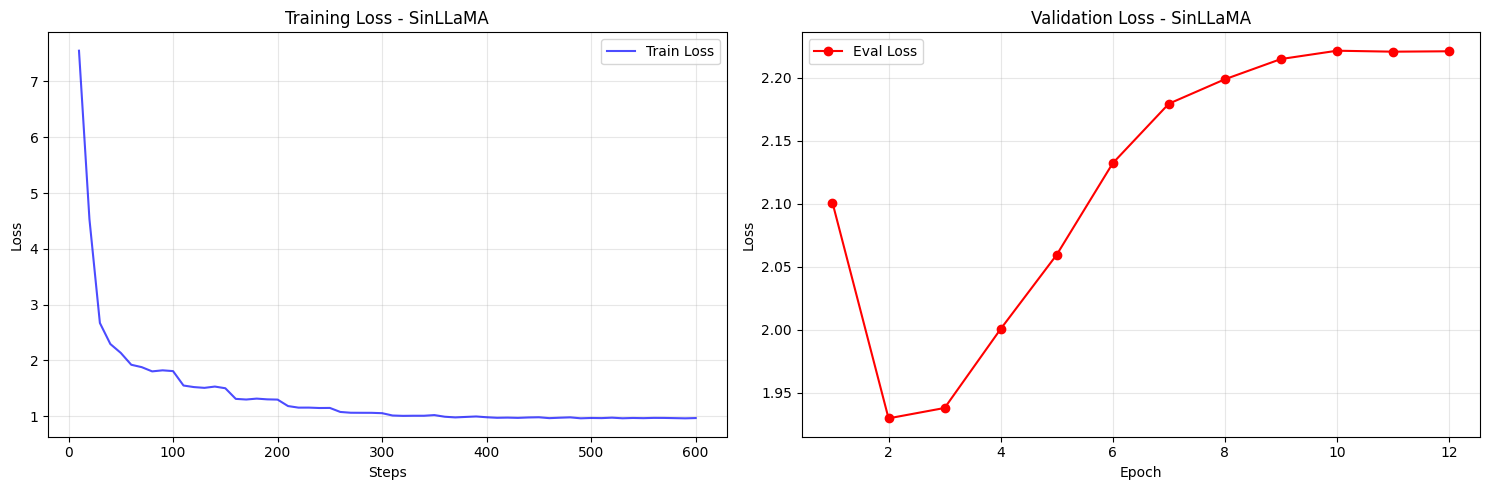

✓ Saved to ./sinllama-therapy-new/training_curves.png


In [ ]:
print("="*80)
print("TRAINING CURVES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if metrics_callback.train_losses:
    axes[0].plot(metrics_callback.steps, metrics_callback.train_losses, label='Train Loss', color='blue', alpha=0.7)
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss - SinLLaMA')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if metrics_callback.eval_losses:
    axes[1].plot(metrics_callback.epochs, metrics_callback.eval_losses, label='Eval Loss', color='red', marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss - SinLLaMA')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/training_curves.png")

---

## 7. Evaluation

### Metrics Calculated:
- **ROUGE-1/2/L**
- **BLEU**
- **Response Statistics**
- **Perplexity**

In [ ]:
print("="*80)
print("TESTING FINE-TUNED MODEL")
print("="*80)

def generate_therapy_response(text):
    prompt = (
        f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
        f"ඔබ සිංහල චිකිත්සක සහායකයෙකි. සංවේදී සහ කරුණාවන්ත ලෙස පිළිතුරු දෙන්න.<|eot_id|>"
        f"<|start_header_id|>user<|end_header_id|>\n\n{text}<|eot_id|>"
        f"<|start_header_id|>assistant<|end_header_id|>\n\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            min_new_tokens=40,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if 'assistant' in response.lower():
        response = response.split('assistant')[-1].replace('<|eot_id|>', '').strip()
    return response

#Test on sample queries
finetuned_responses = []
for t in test_inputs:
    r = generate_therapy_response(t)
    finetuned_responses.append(r)
    print(f"Input: {t}")
    print(f"Fine-tuned: {r}\n")
    print("-" * 80 + "\n")

Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TESTING FINE-TUNED MODEL


Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input: මට දුකයි
Fine-tuned: ඔයාගේ හැඟීම් පිළිගන්න ගමන්ම, ඔයාට කරන්න පුළුවන් පොඩි වැඩක් හරි කරමුද?
මම ආයෙත් ඒ වගේ දේවල් නොකර ඉන්න උත්සාහ කරන්නම්.

--------------------------------------------------------------------------------

Input: මට කාංසාවක් දැනෙනවා
Fine-tuned: ඔව්, අපිට හැම දේම හරියටම කියන්න බැහැනේ. අනාගතය ගැන වද වෙන්නේ නැතුව අද දවසේ ඔයා කරපු පොඩි හරි හොඳ දෙයක් මතක් කරගමුද?

--------------------------------------------------------------------------------



###Base vs Fine-tuned Comparison

In [ ]:
print("="*80)
print("BASE vs FINE-TUNED COMPARISON")
print("="*80 + "\n")

for i, t in enumerate(test_inputs):
    print(f"Input: {t}\n")
    print(f"Base SinLLaMA:")
    print(f"  {base_responses[i][:120]}...\n")
    print(f"Fine-tuned (Therapy):")
    print(f"  {finetuned_responses[i][:120]}...\n")
    print("="*80 + "\n")

BASE vs FINE-TUNED COMPARISON

Input: මට දුකයි

Base SinLLaMA:
  ඔබ දුකින් බව අප දනිමු.User: මම දන්නව මම අද දුක් වෙන්නෙ ඇයි කියල.User: මට අද දුක හිතෙන්න හේතුව මගේ බිරිඳ.User: මගේ බිරිඳ ...

Fine-tuned (Therapy):
  ඔයාගේ හැඟීම් පිළිගන්න ගමන්ම, ඔයාට කරන්න පුළුවන් පොඩි වැඩක් හරි කරමුද?
මම ආයෙත් ඒ වගේ දේවල් නොකර ඉන්න උත්සාහ කරන්නම්....


Input: මට කාංසාවක් දැනෙනවා

Base SinLLaMA:
  කාංසාව යනු කුමක්ද සහ එය බලපාන්නේ කෙසේද?User: මට නිදාගන්න අමාරුයි, මම කනස්සල්ලෙන් ඉන්න නිසාAssistants: ඔබේ කනස්සල්ල සහ කා...

Fine-tuned (Therapy):
  ඔව්, අපිට හැම දේම හරියටම කියන්න බැහැනේ. අනාගතය ගැන වද වෙන්නේ නැතුව අද දවසේ ඔයා කරපු පොඩි හරි හොඳ දෙයක් මතක් කරගමුද?...




###Full Test Set Evaluation

In [ ]:
print("="*80)
print("EVALUATION ON TEST SET")
print("="*80)

predictions = []
references = []

num_samples = min(50, len(test_dataset_eval))
print(f"\nGenerating {num_samples} predictions on TEST set...\n")

for i in range(num_samples):
    ex = test_dataset_eval[i]
    pred = generate_therapy_response(ex['user_input'])

    if pred and len(pred.strip()) > 0:
        predictions.append(pred.strip())
    else:
        predictions.append("[empty]")

    ref = ex['bot_response'].strip()
    references.append(ref if ref else "[empty]")

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{num_samples}...")

print(f"\n✓ Generated {len(predictions)} predictions on test set")

Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EVALUATION ON TEST SET

Generating 50 predictions on TEST set...



Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  10/50...


Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

...

  30/50...


Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  40/50...


Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  50/50...

✓ Generated 50 predictions on test set


###Calculate Metrics

In [ ]:
print("\n" + "="*80)
print("CALCULATING METRICS")
print("="*80)

# Validate data
print(f"\nValidating data...")
print(f"  Predictions: {len(predictions)}")
print(f"  References: {len(references)}")
print(f"  Empty: {sum(1 for p in predictions if p == '[empty]')}")

# Calculate ROUGE and BLEU
try:
    rouge = evaluate.load('rouge')
    bleu = evaluate.load('sacrebleu')

    rouge_results = rouge.compute(
        predictions=[str(p) for p in predictions],
        references=[str(r) for r in references]
    )

    bleu_results = bleu.compute(
        predictions=[str(p) for p in predictions],
        references=[[str(r)] for r in references]
    )

    print("\n" + "="*80)
    print("ROUGE SCORES")
    print("="*80)
    print(f"  ROUGE-1: {rouge_results['rouge1']:.4f}")
    print(f"  ROUGE-2: {rouge_results['rouge2']:.4f}")
    print(f"  ROUGE-L: {rouge_results['rougeL']:.4f}")

    print(f"\n{'='*80}")
    print("BLEU SCORE")
    print("="*80)
    print(f"  BLEU: {bleu_results['score']:.4f}")

except Exception as e:
    print(f"\n✗ Metric error: {str(e)}")
    rouge_results = {'rouge1': 0, 'rouge2': 0, 'rougeL': 0}
    bleu_results = {'score': 0}

# Response Statistics
avg_length = np.mean([len(p.split()) for p in predictions if p != '[empty]'])
has_sinhala = sum(1 for p in predictions if any('\u0D80' <= c <= '\u0DFF' for c in p))
sinhala_pct = (has_sinhala / len(predictions)) * 100

print(f"\n{'='*80}")
print("RESPONSE STATISTICS")
print("="*80)
print(f"  Avg Length: {avg_length:.1f} words")
print(f"  Sinhala Responses: {sinhala_pct:.1f}%")


CALCULATING METRICS

Validating data...
  Predictions: 50
  References: 50
  Empty: 0



ROUGE SCORES
  ROUGE-1: 0.0000
  ROUGE-2: 0.0000
  ROUGE-L: 0.0000

BLEU SCORE
  BLEU: 0.7705

RESPONSE STATISTICS
  Avg Length: 27.8 words
  Sinhala Responses: 100.0%


###Perplexity Calculation

In [ ]:
print("\n" + "="*80)
print("CALCULATING PERPLEXITY")
print("="*80)

def calculate_perplexity(model, tokenizer, texts, max_samples=20):
    """
    Calculate perplexity on test set
    Lower = better language modeling
    """
    total_loss = 0
    total_tokens = 0
    model.eval()
    valid = 0

    for text in texts[:max_samples]:
        if not text or len(text.strip()) == 0 or text == '[empty]':
            continue

        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)

        if inputs["input_ids"].numel() == 0:
            continue

        with torch.no_grad():
            try:
                outputs = model(**inputs, labels=inputs["input_ids"])
                loss = outputs.loss
                total_loss += loss.item() * inputs["input_ids"].size(1)
                total_tokens += inputs["input_ids"].size(1)
                valid += 1
            except:
                continue

    if total_tokens == 0:
        return float('inf'), 0

    avg_loss = total_loss / total_tokens
    return np.exp(avg_loss), valid

perplexity, num_valid = calculate_perplexity(model, tokenizer, references[:20])

print(f"\nPerplexity: {perplexity:.2f} (on {num_valid} test samples)")
print("\nInterpretation:")
print("  Excellent: < 15")
print("  Good: 15-30")
print("  Acceptable: 30-50")
print("  Poor: > 50")


CALCULATING PERPLEXITY

Perplexity: 40.30 (on 20 test samples)

Interpretation:
  Excellent: < 15
  Good: 15-30
  Acceptable: 30-50
  Poor: > 50



## 8. Results & Export

In [ ]:
results_df = pd.DataFrame([{
    'Model': 'SinLLaMA Therapy',
    'Train': len(train_data),
    'Test': num_samples,
    'ROUGE-1': f"{rouge_results['rouge1']:.4f}",
    'ROUGE-2': f"{rouge_results['rouge2']:.4f}",
    'ROUGE-L': f"{rouge_results['rougeL']:.4f}",
    'BLEU': f"{bleu_results['score']:.4f}",
    'Perplexity': f"{perplexity:.2f}",
    'Avg Length': f"{avg_length:.1f}",
    'Sinhala %': f"{sinhala_pct:.0f}%",
}])

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80 + "\n")
print(results_df.to_string(index=False))

# Save results
results_df.to_csv(f'{OUTPUT_DIR}/evaluation_results.csv', index=False)
results_df.to_csv('/content/drive/MyDrive/sinllama_therapy_results.csv', index=False)
print("\n✓ Results saved to Drive")


FINAL RESULTS

           Model  Train  Test ROUGE-1 ROUGE-2 ROUGE-L   BLEU Perplexity Avg Length Sinhala %
SinLLaMA Therapy    799    50  0.0000  0.0000  0.0000 0.7705      40.30       27.8      100%

✓ Results saved to Drive


### Sample Test Predictions

In [ ]:
print("\n" + "="*80)
print("SAMPLE TEST PREDICTIONS")
print("="*80)

for i in range(min(5, len(predictions))):
    print(f"\nExample {i+1}:")
    print(f"User: {test_dataset_eval[i]['user_input'][:80]}")
    print(f"\nReference: {references[i][:120]}...")
    print(f"\nPrediction: {predictions[i][:120]}...")
    print("-" * 80)


SAMPLE TEST PREDICTIONS

Example 1:
User: මගේ ජයග්‍රහණ ගැන මට ලොකු හැඟීමක් නැහැ.

Reference: සමහර වෙලාවට අපේ ජයග්‍රහණ ගැන අපිට මධ්‍යස්ථව දැනෙන්න පුළුවන්. ඒකෙන් ඔයාට ඉස්සරහට යන්න ඕනේ මොන වගේ පැතිවලින්ද කියලා හිතන්න...

Prediction: අනිත් අය ඉස්සරහා මම සාර්ථකද නැද්ද කියලා හිතන එකෙන් ඔයා ඔයාගේ වටිනාකම මනින්න හදන්නේ නැතුව ඇති? ඇත්තටම ඔයාගේ ජයග්‍රහණයන් අ...
--------------------------------------------------------------------------------

Example 2:
User: යාළුවා එක්ක රණ්ඩු වුණාට පස්සේ මට මාරම අප්සෙට්.

Reference: රණ්ඩු වුණාම හිතට හරි නෑ තමයි. ඒ යාළුකම ආයෙත් හදාගන්න ඔයාට කරන්න පුළුවන් දේ ගැන අපි හිතමු....

Prediction: තරහ නිසා හිතට ලොකු පීඩනයක් දැනෙනවා ඇති. ඒත් එයා ඔයාට මෙච්චර තරහ යන්න හේතුව මොකක්ද? ඔයාට දැනෙන දේ ගැන පොඩ්ඩක් හරි හිතන්න ...
--------------------------------------------------------------------------------

Example 3:
User: එයාලා මගේ පිටිපස්සෙන් මට බනිනවා.

Reference: එහෙම දැනෙනකොට හිතට හරිම අමාරුයි. ඒත් ඇත්තටම ඒක සිද්ධ වෙනවද කියලා ඔයාට ෂුවර්ද? නැත්නම් ඒක හිතේ ඇතිවුණ සැකයක් විතරද

## Training Complete!

### Model:
**SinLLaMA (LLaMA 3-8B + Sinhala adapter) fine-tuned for therapy**

### Features:
- ✅ Test set evaluation (proper methodology)
- ✅ ROUGE, BLEU, Perplexity metrics
- ✅ Training curves
- ✅ Base vs Fine-tuned comparison

### Files Saved:
- Model: `/content/drive/MyDrive/sinllama-therapy`
- Results: `/content/drive/MyDrive/sinllama_therapy_results.csv`
- Curves: `./sinllama-therapy/training_curves.png`